In [13]:
import numpy as np
import pandas as pd
import scanpy as sc
import plotnine as p9
import liana as li
import muon as mu
import anndata as ad
import matplotlib.pyplot as plt
import squidpy as sq
from liana.method._pipe_utils._common import _get_props
from liana.method.sp._utils import _add_complexes_to_var
from liana._logging import _logg
from liana.method._pipe_utils import prep_check_adata, assert_covered
from scipy.sparse import csr_matrix
#from liana.method.sp._inflow import inflow

In [3]:
adata = sc.read("/g/stegle/aalsayah/repos/data/crc_wt_cosmx/232_processed_moran.h5ad")

In [ ]:
adata 

AnnData object with n_obs × n_vars = 129915 × 18935
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68_CK8_18', 'Max.CD68_CK8_18', 'Mean.CD298_B2M', 'Max.CD298_B2M', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'Dash', 'ISH.concentration', 'Panel', 'Run_Tissue_name', 'Run_name', 'assay_type', 'dualfiles', 'tissue', 'version', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'cell_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_0.8', 'falsecode_quantil

In [ ]:
# Normalize counts per cell
sc.pp.normalize_total(adata, target_sum=1e4)

# Logarithmize the data
sc.pp.log1p(adata)

# Optionally, select highly variable genes
sc.pp.highly_variable_genes(adata, n_top_genes=2000, subset=True, flavor="seurat")

In [6]:
sc.pp.scale(adata, max_value=10)

/g/stegle/aalsayah/Miniforge3/envs/liana_env/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.


In [ ]:
sc.pp.pca(adata)

In [7]:
sc.pp.neighbors(adata)

/g/stegle/aalsayah/Miniforge3/envs/liana_env/lib/python3.10/site-packages/scanpy/neighbors/__init__.py:586: UserWarning: You’re trying to run this on 2000 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.


In [8]:
sc.tl.umap(adata)

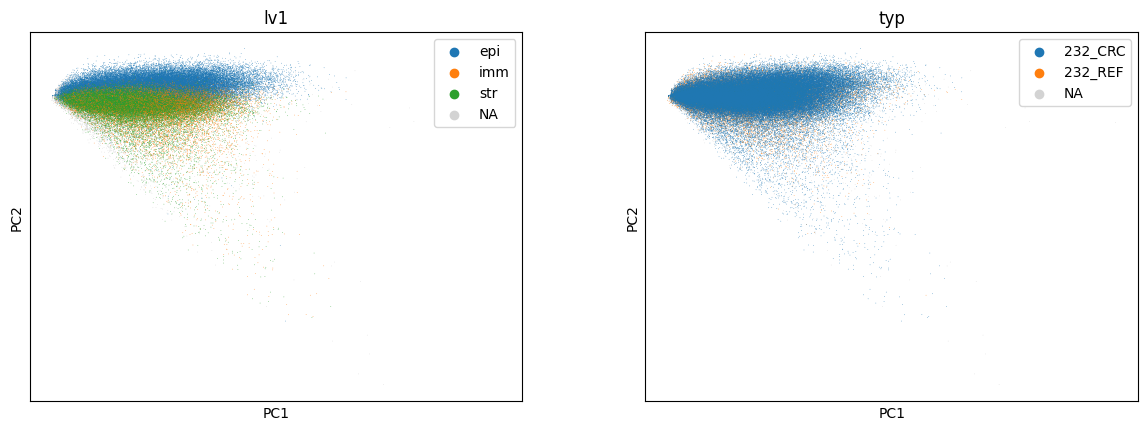

In [10]:
sc.pl.pca(adata, color=["lv1", "typ"], legend_loc="upper right") 

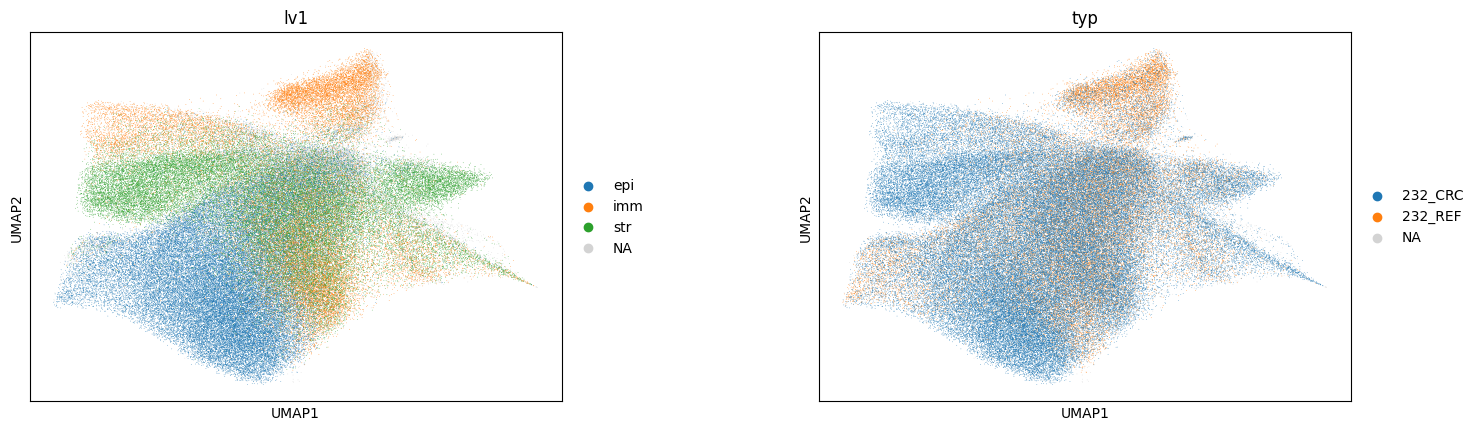

In [11]:
sc.pl.umap(adata, color=['lv1', 'typ'], wspace=0.35)

In [17]:
lr = li.rs.select_resource()
ligand_set = set(lr['ligand']) #1027
receptor_set = set(lr['receptor']) #1052

In [18]:
union_set = ligand_set | receptor_set

In [19]:
len(union_set)

2017

In [44]:
adata = sc.read("/g/stegle/aalsayah/repos/data/crc_wt_cosmx/232_processed_moran.h5ad")

In [45]:
# Normalize counts per cell
sc.pp.normalize_total(adata, target_sum=1e4)

# Logarithmize the data
sc.pp.log1p(adata)


In [46]:
# Keep genes that are both in the data and in union_set (order of var_names preserved)
genes_in_data = [g for g in adata.var_names if g in union_set]

In [47]:
len(genes_in_data)

1820

In [48]:
adata_sub = adata[:, genes_in_data].copy()

In [49]:
adata_sub

AnnData object with n_obs × n_vars = 129915 × 1820
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68_CK8_18', 'Max.CD68_CK8_18', 'Mean.CD298_B2M', 'Max.CD298_B2M', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'Dash', 'ISH.concentration', 'Panel', 'Run_Tissue_name', 'Run_name', 'assay_type', 'dualfiles', 'tissue', 'version', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'cell_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_0.8', 'falsecode_quantile

In [50]:
sc.pp.neighbors(adata_sub)
sc.tl.umap(adata_sub)

/g/stegle/aalsayah/Miniforge3/envs/liana_env/lib/python3.10/site-packages/scanpy/neighbors/__init__.py:586: UserWarning: You’re trying to run this on 1820 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.


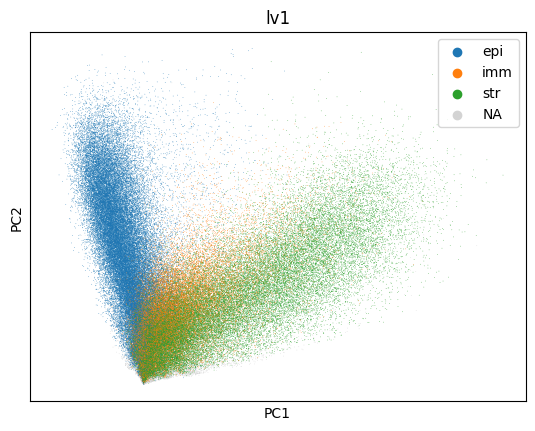

In [51]:
sc.pl.pca(adata_sub, color=["lv1"], legend_loc="upper right") 

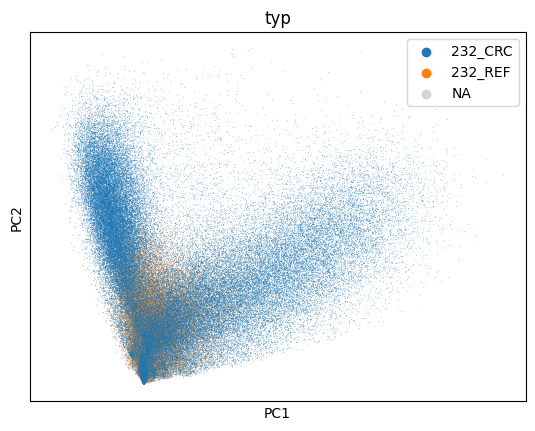

In [54]:
sc.pl.pca(adata_sub, color=["typ"], legend_loc="upper right") 

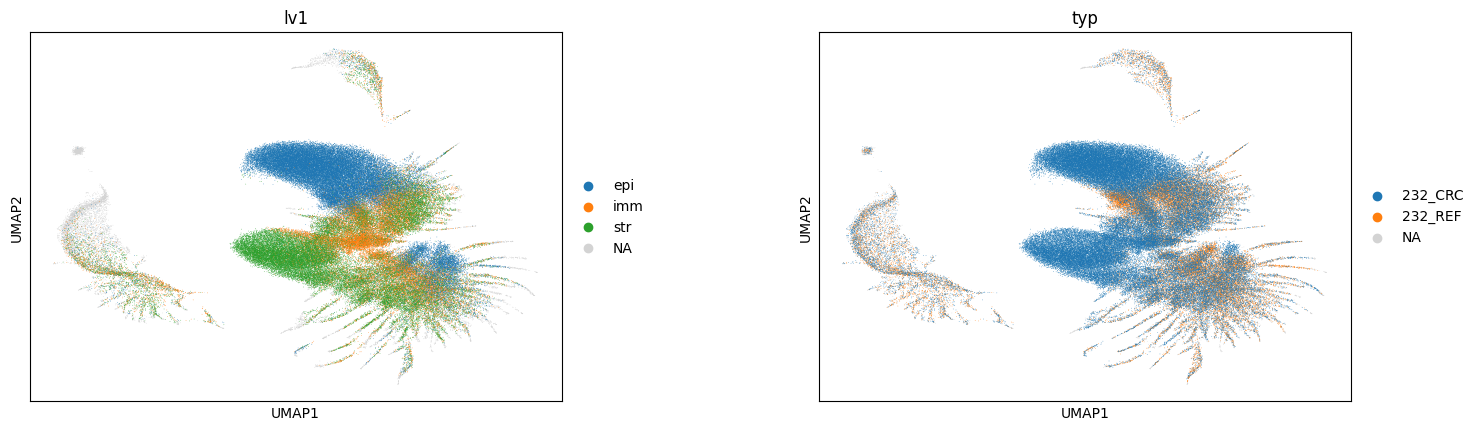

In [52]:
sc.pl.umap(adata_sub, color=['lv1', 'typ'], wspace=0.35)

#2nd dataset

In [4]:
adata = sc.read("/g/stegle/aalsayah/repos/data/crc_wt_cosmx/crc_231.h5ad")

In [5]:
#QC
sc.pp.filter_cells(adata, min_genes=10)
sc.pp.filter_genes(adata, min_cells=3)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

## All genes

In [6]:
adata2= adata.copy()

In [7]:
# Optionally, select highly variable genes
sc.pp.highly_variable_genes(adata2, n_top_genes=3000, subset=True, flavor="seurat")

In [8]:
sc.pp.scale(adata2, max_value=10)

/g/stegle/aalsayah/Miniforge3/envs/liana_env/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.


In [ ]:
# --- PCA / neighbors with explicit settings ---
sc.tl.pca(adata2, svd_solver='arpack', n_comps=50, random_state=0)

In [ ]:
sc.pp.neighbors(adata2, n_neighbors=20, n_pcs=40, metric='euclidean')  # tune n_neighbors 15–30

In [9]:
# --- UMAP (control layout) ---
sc.tl.umap(adata2, min_dist=0.3, spread=1.0, random_state=0)

KeyboardInterrupt: 

In [ ]:
sc.pl.umap(adata2, color=['lv1', 'typ'], wspace=0.35)

In [ ]:
sc.pl.pca(adata2, color=["lv1", "typ"], legend_loc="upper right") 

## LR genes

In [40]:
genes_in_data = [g for g in adata.var_names if g in union_set]
adata_sub = adata[:, genes_in_data].copy()
len(genes_in_data)

1820

In [ ]:
sc.pp.scale(adata_sub, max_value=10)

/g/stegle/aalsayah/Miniforge3/envs/liana_env/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.


In [ ]:
# --- PCA / neighbors with explicit settings ---
sc.tl.pca(adata_sub, svd_solver='arpack', n_comps=50, random_state=0)

In [ ]:
sc.pp.neighbors(adata_sub, n_neighbors=20, n_pcs=40, metric='euclidean')  # tune n_neighbors 15–30

In [ ]:
# --- UMAP (control layout) ---
sc.tl.umap(adata_sub, min_dist=0.3, spread=1.0, random_state=0)

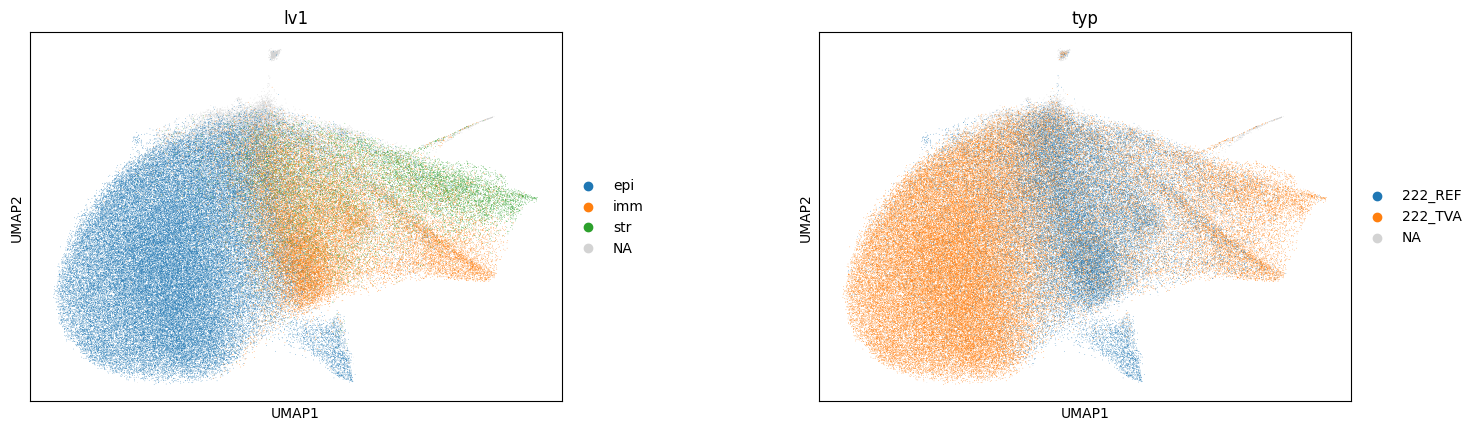

In [45]:
sc.pl.umap(adata_sub, color=['lv1', 'typ'], wspace=0.35)

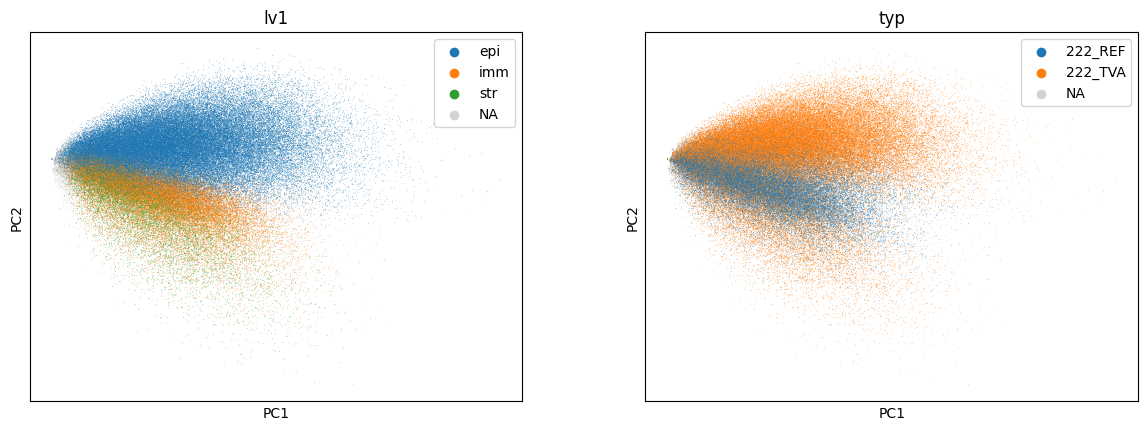

In [46]:
sc.pl.pca(adata_sub, color=["lv1", "typ"], legend_loc="upper right") 